# Week 8 - Pattern Recognition


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score


In [3]:
from google.colab import files

uploaded = files.upload()

df=pd.read_csv("Combined_Dataset.csv")
print(df.shape)
print(df.head())

if "Anomaly" in df.columns:
    df["Anomaly"]=df["Anomaly"].astype(int)

df["Rolling Mean"]=df["Lux"].rolling(5,min_periods=1).mean()
df["Rolling Std"]=df["Lux"].rolling(5,min_periods=1).std().fillna(0)
df["Difference"]=df["Lux"].diff().fillna(0)

features=["Lux","Smoothed Lux","Rolling Mean","Rolling Std","Difference"]
if "Anomaly" in df.columns:
    features.append("Anomaly")


Saving Combined_Dataset.csv to Combined_Dataset (1).csv
(111297, 4)
   Reading      Lux  Anomaly  Smoothed Lux
0    15411    82.50    False        82.500
1    24468  6159.17    False      6159.170
2    32479     5.00    False         4.332
3    21753   135.83    False       136.830
4     4708    29.17    False        29.170


In [4]:
sample_size=min(5000,len(df))
sample=df.sample(n=sample_size,random_state=42).reset_index(drop=True)

X=sample[features]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled.shape)


(5000, 6)


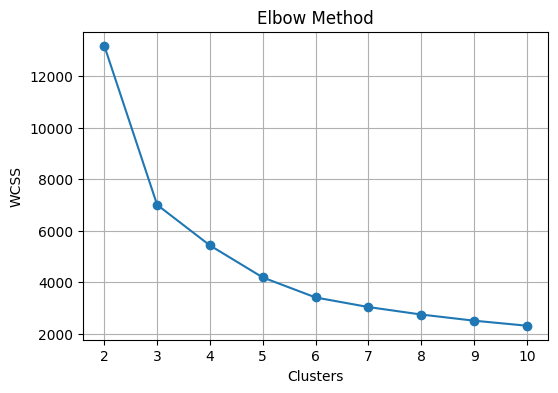

In [5]:
wcss=[]
for k in range(2,11):
    km=KMeans(n_clusters=k,n_init=10,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.grid()
plt.show()


In [6]:
os.makedirs("models",exist_ok=True)

kmeans=KMeans(n_clusters=3,n_init=10,random_state=42)
k_labels=kmeans.fit_predict(X_scaled)
joblib.dump(kmeans,"models/kmeans_model.pkl")

agg=AgglomerativeClustering(n_clusters=3)
a_labels=agg.fit_predict(X_scaled)

print("KMeans")
print("Silhouette:",silhouette_score(X_scaled,k_labels))
print("Davies:",davies_bouldin_score(X_scaled,k_labels))
print("Calinski:",calinski_harabasz_score(X_scaled,k_labels))

print("\nAgglomerative")
print("Silhouette:",silhouette_score(X_scaled,a_labels))
print("Davies:",davies_bouldin_score(X_scaled,a_labels))
print("Calinski:",calinski_harabasz_score(X_scaled,a_labels))


KMeans
Silhouette: 0.5428262293150902
Davies: 0.7518313102661921
Calinski: 6416.800811199427

Agglomerative
Silhouette: 0.4971287791840331
Davies: 0.7574319523862801
Calinski: 4646.8056396619


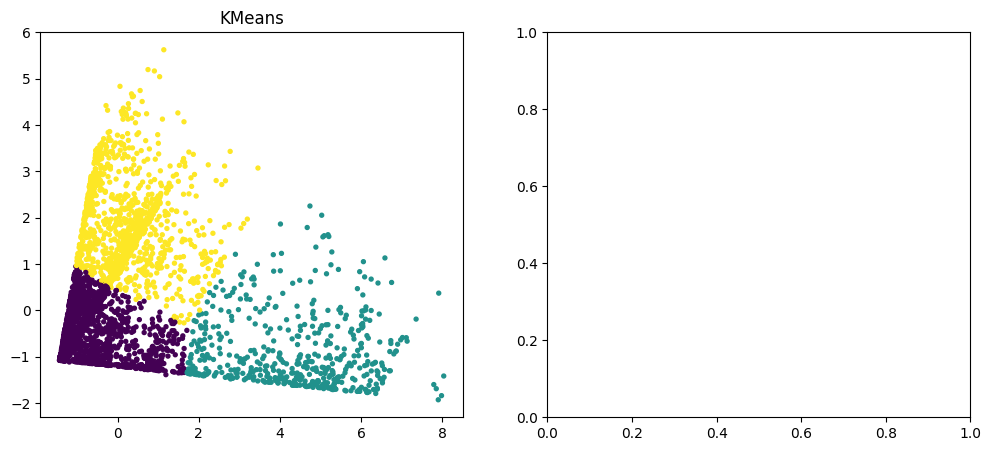

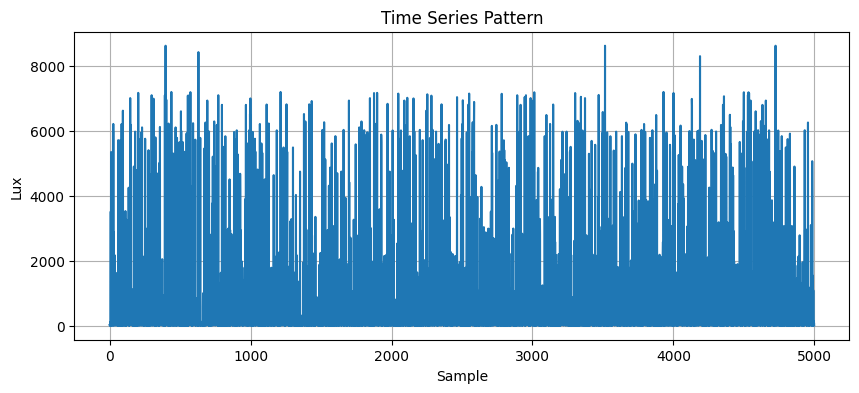

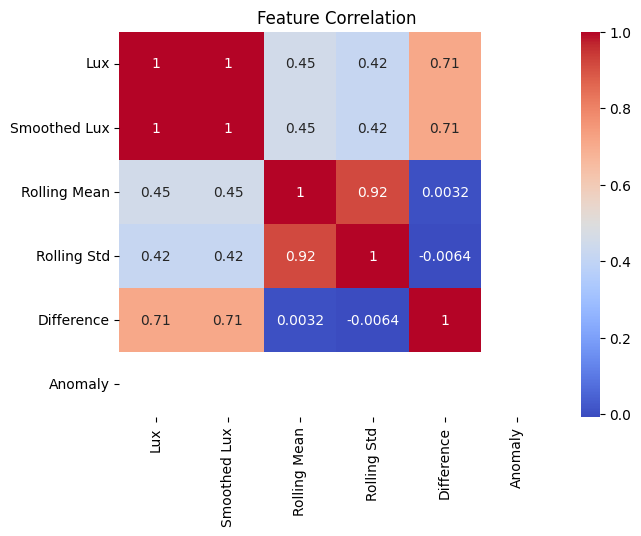

Saved Pattern_Recognition_Output.csv


In [8]:
pca=PCA(n_components=2)
p=pca.fit_transform(X_scaled)

fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].scatter(p[:,0],p[:,1],c=k_labels,s=8,cmap="viridis")
ax[0].set_title("KMeans")

plt.figure(figsize=(10,4))
plt.plot(sample["Lux"].values)
plt.title("Time Series Pattern")
plt.xlabel("Sample")
plt.ylabel("Lux")
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
sns.heatmap(sample[features].corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

sample["Cluster"]=k_labels
sample.to_csv("Pattern_Recognition_Output.csv",index=False)
print("Saved Pattern_Recognition_Output.csv")
